# 🍽️ Zomato Restaurant Data - Exploratory Data Analysis

**Author:** Nakul  
**Dataset:** Zomato Restaurants Dataset  
**Tools:** Python, Pandas, Matplotlib, Seaborn

---

## 📌 Objective
Analyze Zomato restaurant data to uncover insights about:
- Restaurant ratings and popularity
- Online ordering & table booking trends
- Cost distribution
- Restaurant type breakdown


## 1. 📦 Import Libraries & Load Data

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load dataset
df = pd.read_csv('Zomato-data-.csv')
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [41]:
import os
print(os.getcwd())

C:\Users\Admin\Downloads


## 2. 🔍 Dataset Overview

In [42]:
print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Shape: (148, 7)

Column Names: ['name', 'online_order', 'book_table', 'rate', 'votes', 'approx_cost(for two people)', 'listed_in(type)']

Data Types:
name                             str
online_order                     str
book_table                       str
rate                             str
votes                          int64
approx_cost(for two people)    int64
listed_in(type)                  str
dtype: object


In [43]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


In [44]:
df.describe(include='all')

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
count,148,148,148,148,148.000000,148.000000,148
unique,145,2,2,20,NaN,NaN,4
top,San Churro Cafe,No,No,3.8/5,NaN,NaN,Dining
freq,2,90,140,19,NaN,NaN,110
mean,NaN,NaN,NaN,NaN,264.810811,418.243243,NaN
std,NaN,NaN,NaN,NaN,653.676951,223.085098,NaN
min,NaN,NaN,NaN,NaN,0.000000,100.000000,NaN
25%,NaN,NaN,NaN,NaN,6.750000,200.000000,NaN
50%,NaN,NaN,NaN,NaN,43.500000,400.000000,NaN
75%,NaN,NaN,NaN,NaN,221.750000,600.000000,NaN


## 3. 🧹 Data Cleaning

In [45]:
# Convert 'rate' column from '4.1/5' to float 4.1
def clean_rate(value):
    try:
        return float(str(value).split('/')[0])
    except:
        return np.nan

df['rate'] = df['rate'].apply(clean_rate)
print("Rate column cleaned!")
print(df['rate'].describe())

Rate column cleaned!
count    148.000000
mean       3.633108
std        0.402271
min        2.600000
25%        3.300000
50%        3.700000
75%        3.900000
max        4.600000
Name: rate, dtype: float64


In [46]:
# Rename columns for easier use
df.rename(columns={
    'approx_cost(for two people)': 'cost_for_two',
    'listed_in(type)': 'restaurant_type'
}, inplace=True)

print("Columns renamed!")
df.head()

Columns renamed!


,name,online_order,book_table,rate,votes,cost_for_two,restaurant_type
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


## 4. 📊 Exploratory Data Analysis

### 4.1 Online Order Distribution

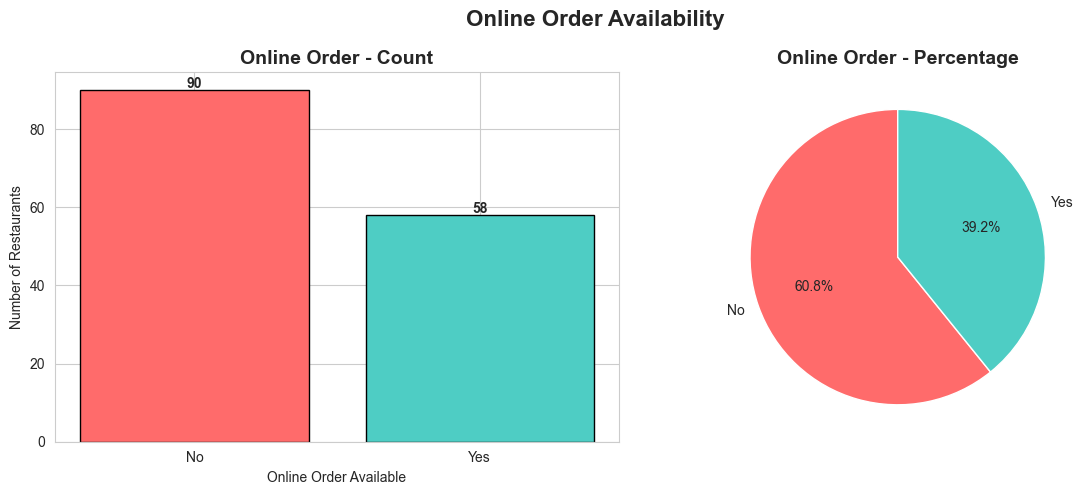


✅ Insight: Most restaurants offer online ordering.


In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
order_counts = df['online_order'].value_counts()
axes[0].bar(order_counts.index, order_counts.values, color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[0].set_title('Online Order - Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Online Order Available')
axes[0].set_ylabel('Number of Restaurants')
for i, v in enumerate(order_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(order_counts.values, labels=order_counts.index, autopct='%1.1f%%',
            colors=['#FF6B6B', '#4ECDC4'], startangle=90)
axes[1].set_title('Online Order - Percentage', fontsize=14, fontweight='bold')

plt.suptitle('Online Order Availability', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('online_order.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Insight: Most restaurants offer online ordering.")

### 4.2 Table Booking Distribution

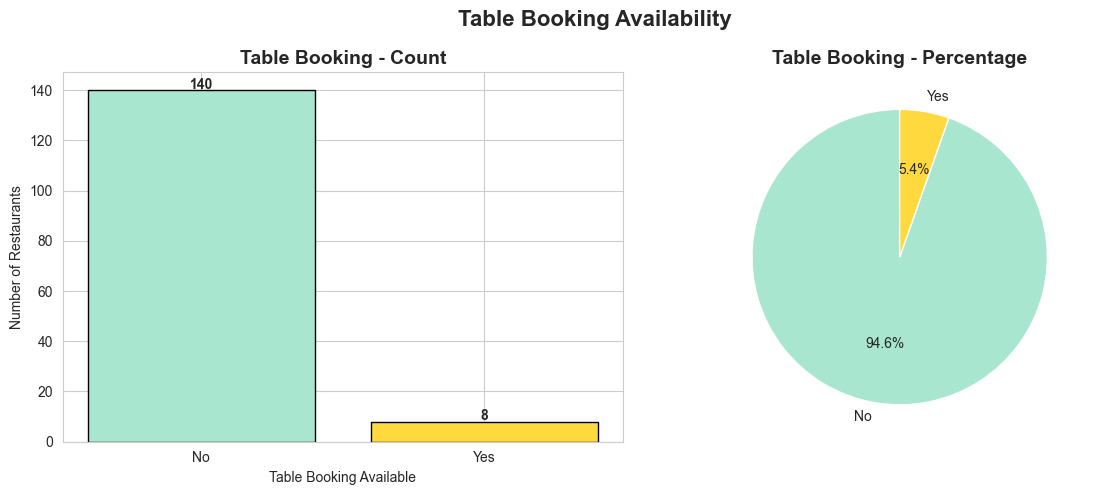


✅ Insight: Very few restaurants offer table booking.


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

book_counts = df['book_table'].value_counts()
axes[0].bar(book_counts.index, book_counts.values, color=['#A8E6CF', '#FFD93D'], edgecolor='black')
axes[0].set_title('Table Booking - Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Table Booking Available')
axes[0].set_ylabel('Number of Restaurants')
for i, v in enumerate(book_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

axes[1].pie(book_counts.values, labels=book_counts.index, autopct='%1.1f%%',
            colors=['#A8E6CF', '#FFD93D'], startangle=90)
axes[1].set_title('Table Booking - Percentage', fontsize=14, fontweight='bold')

plt.suptitle('Table Booking Availability', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('table_booking.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Insight: Very few restaurants offer table booking.")

### 4.3 Rating Distribution

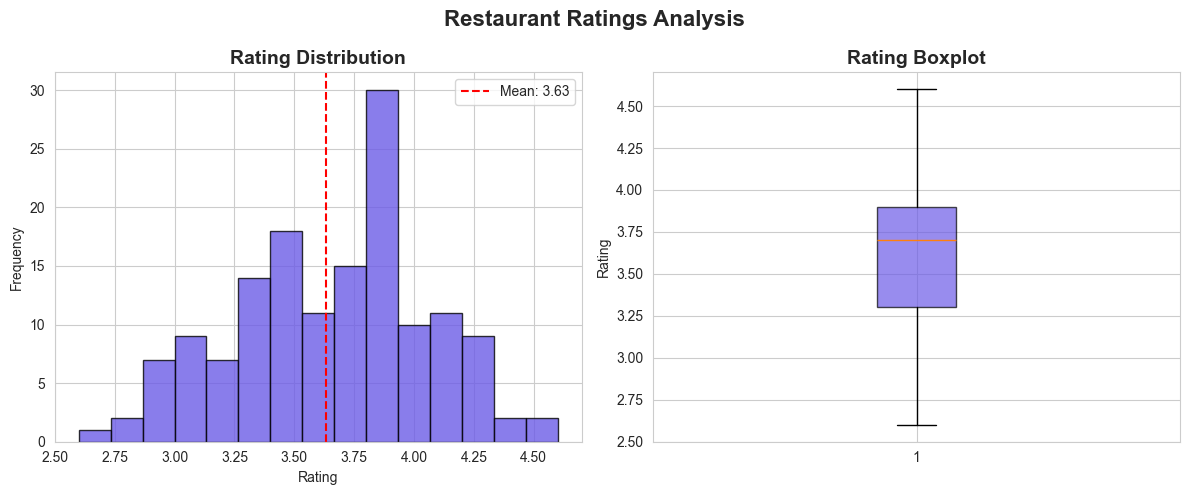


✅ Average Rating: 3.63
✅ Most restaurants are rated between 3.3 and 3.9


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(df['rate'].dropna(), bins=15, color='#6C5CE7', edgecolor='black', alpha=0.8)
axes[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['rate'].mean(), color='red', linestyle='--', label=f'Mean: {df["rate"].mean():.2f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['rate'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='#6C5CE7', alpha=0.7))
axes[1].set_title('Rating Boxplot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Rating')

plt.suptitle('Restaurant Ratings Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Average Rating: {df['rate'].mean():.2f}")
print(f"✅ Most restaurants are rated between {df['rate'].quantile(0.25):.1f} and {df['rate'].quantile(0.75):.1f}")

### 4.4 Votes Distribution

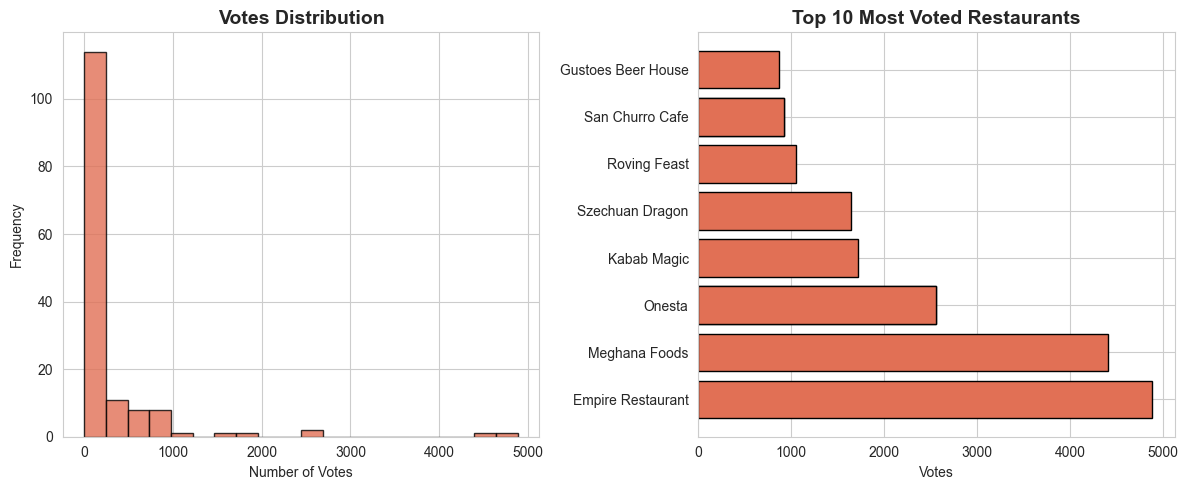

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['votes'], bins=20, color='#E17055', edgecolor='black', alpha=0.8)
axes[0].set_title('Votes Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Votes')
axes[0].set_ylabel('Frequency')

# Top 10 restaurants by votes
top10 = df.nlargest(10, 'votes')[['name', 'votes']]
axes[1].barh(top10['name'], top10['votes'], color='#E17055', edgecolor='black')
axes[1].set_title('Top 10 Most Voted Restaurants', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Votes')

plt.tight_layout()
plt.savefig('votes.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Cost for Two Distribution

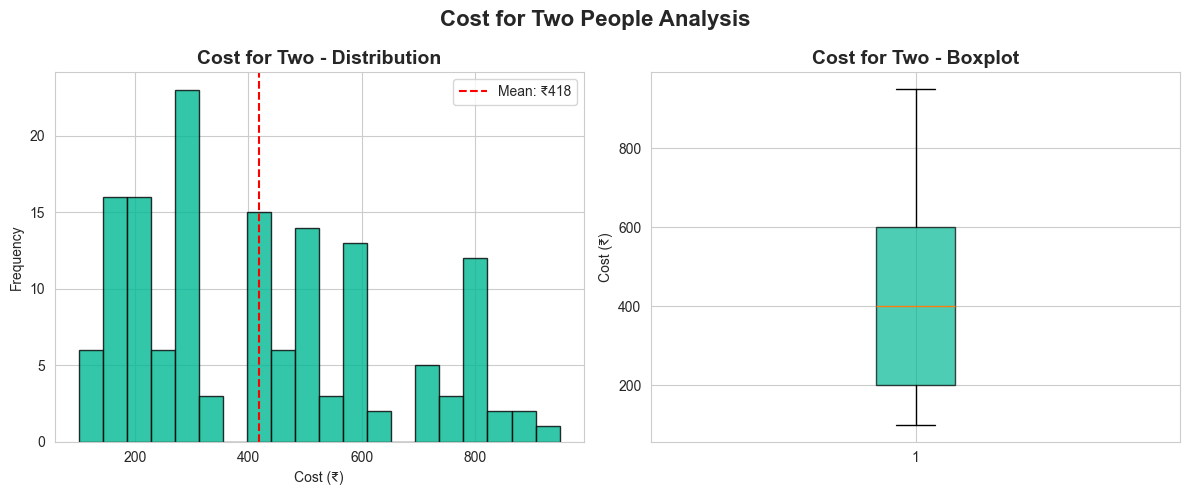


✅ Average cost for two: ₹418
✅ Cost range: ₹100 - ₹950


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['cost_for_two'], bins=20, color='#00B894', edgecolor='black', alpha=0.8)
axes[0].set_title('Cost for Two - Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cost (₹)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['cost_for_two'].mean(), color='red', linestyle='--', 
                label=f'Mean: ₹{df["cost_for_two"].mean():.0f}')
axes[0].legend()

axes[1].boxplot(df['cost_for_two'], patch_artist=True,
                boxprops=dict(facecolor='#00B894', alpha=0.7))
axes[1].set_title('Cost for Two - Boxplot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cost (₹)')

plt.suptitle('Cost for Two People Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('cost_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Average cost for two: ₹{df['cost_for_two'].mean():.0f}")
print(f"✅ Cost range: ₹{df['cost_for_two'].min()} - ₹{df['cost_for_two'].max()}")

### 4.6 Restaurant Type Analysis

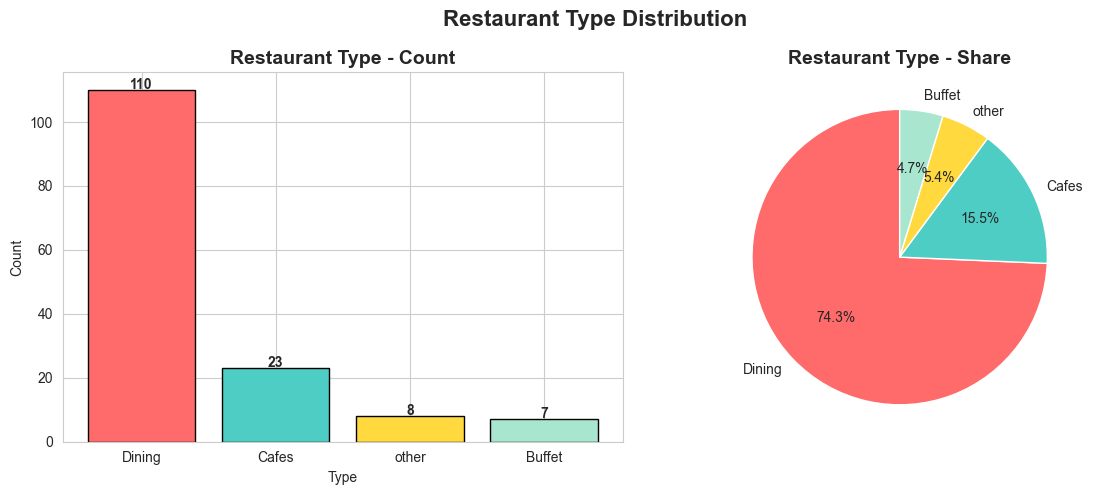

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

type_counts = df['restaurant_type'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#FFD93D', '#A8E6CF']

axes[0].bar(type_counts.index, type_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Restaurant Type - Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Restaurant Type - Share', fontsize=14, fontweight='bold')

plt.suptitle('Restaurant Type Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('restaurant_type.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.7 Rating by Restaurant Type

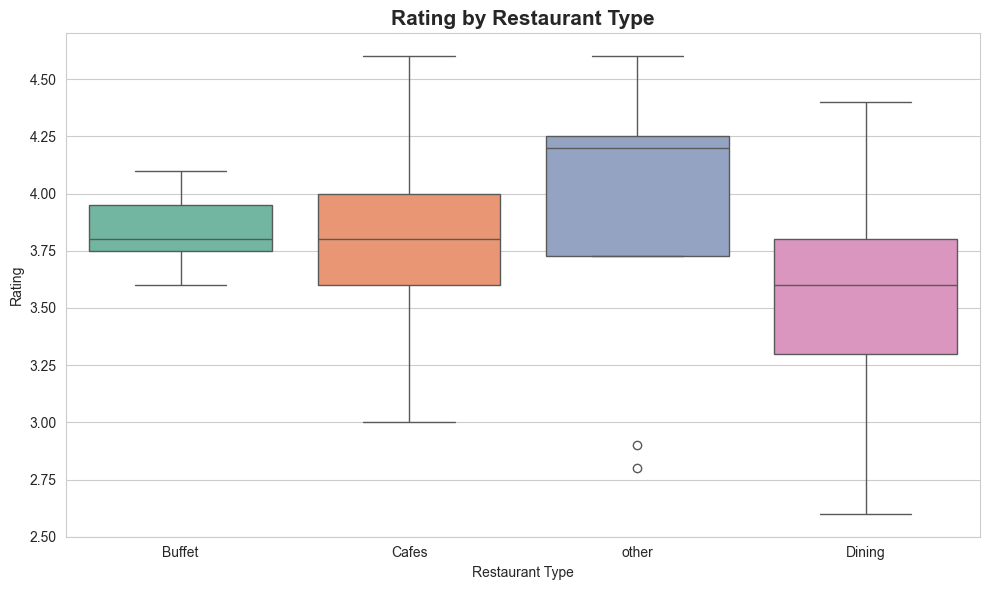

In [53]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='restaurant_type', y='rate', data=df, palette='Set2')
plt.title('Rating by Restaurant Type', fontsize=15, fontweight='bold')
plt.xlabel('Restaurant Type')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('rating_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.8 Online Order vs Rating

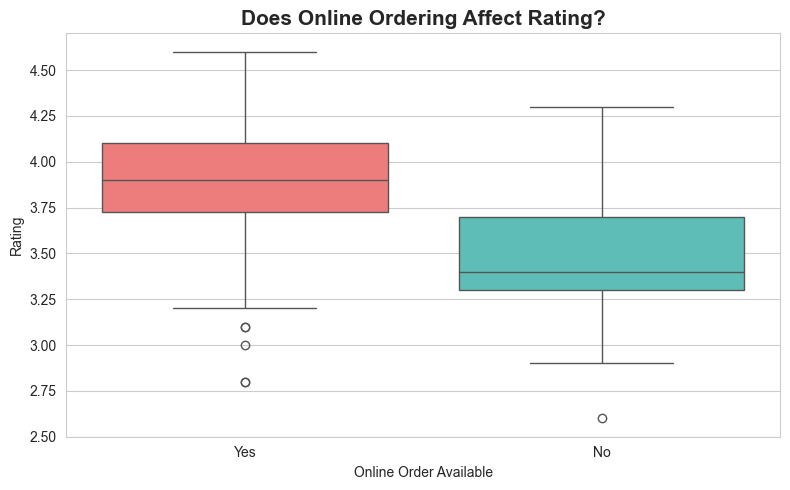

Average rating with online order:
online_order
No     3.49
Yes    3.86
Name: rate, dtype: float64


In [54]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='online_order', y='rate', data=df, palette=['#FF6B6B', '#4ECDC4'])
plt.title('Does Online Ordering Affect Rating?', fontsize=15, fontweight='bold')
plt.xlabel('Online Order Available')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('online_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
print("Average rating with online order:")
print(df.groupby('online_order')['rate'].mean().round(2))

### 4.9 Correlation Heatmap

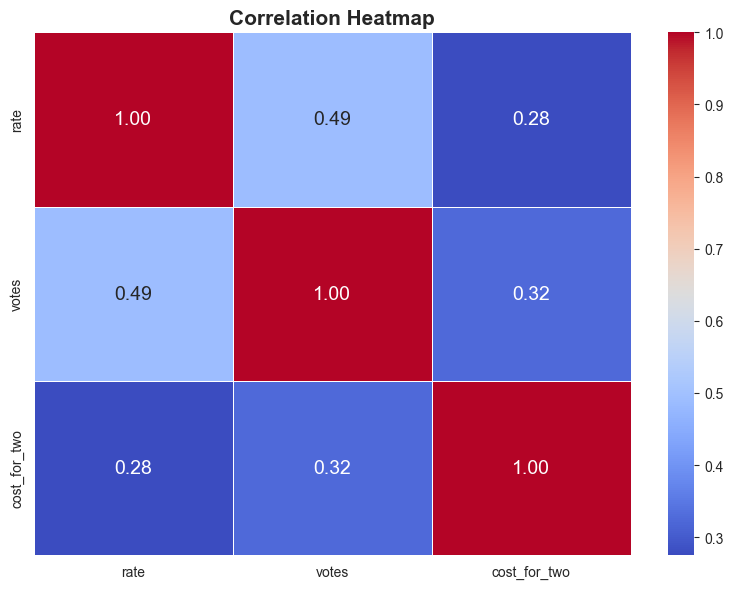


✅ Interpretation:
Positive correlation between votes and ratings means popular restaurants tend to be rated higher.


In [55]:
plt.figure(figsize=(8, 6))
numeric_df = df[['rate', 'votes', 'cost_for_two']]
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,
            annot_kws={"size": 14})
plt.title('Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Interpretation:")
print("Positive correlation between votes and ratings means popular restaurants tend to be rated higher.")

## 5. 📝 Key Insights & Conclusion

### 🔑 Key Findings:

1. **Online Ordering**: Majority of restaurants offer online ordering, indicating a strong digital presence.

2. **Table Booking**: Very few restaurants offer table booking — most are casual dining setups.

3. **Ratings**: Average restaurant rating is around 3.7–4.0/5, indicating generally good quality. Most restaurants fall in the 3.5–4.2 range.

4. **Cost**: Average cost for two people is moderate (₹300–500). There are outliers at both extremes.

5. **Restaurant Types**: Dining is the most common type, followed by Cafes and Buffets.

6. **Online Order vs Rating**: Restaurants with online ordering tend to have slightly higher ratings.

7. **Correlation**: Votes and ratings show a positive correlation — more popular restaurants get better rated.

---

### 🛠️ Tools Used:
- **Python** | **Pandas** | **NumPy** | **Matplotlib** | **Seaborn**

### 📁 Dataset:
- Zomato Restaurants Dataset (148 restaurants, 7 features)
